# P1 — Quantum Desk Calculator
**Qiskit demonstration** · Quantum Computing, University of Verona, AA 2025–2026  
Usama Ahmad · VR513221 · Prof. Alessandra Di Pierro

Reversible circuits for **addition** and **subtraction** of two 3-bit positive integers.
The mapping is

$$
|a\rangle|b\rangle|0\rangle \;\mapsto\; |a\rangle|b\rangle|a\pm b\rangle
$$

Run all cells. Requires `qiskit`, `qiskit-aer` and `matplotlib` (see `requirements.txt`).


## 1. Setup

In [1]:
from calculator import build_adder, build_subtractor
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

backend = AerSimulator()
print("Aer simulator ready")

Aer simulator ready


## 2. Addition: $3 + 5 = 8$

Binary: $3 = 011_2$, $5 = 101_2$. The sum $8 = 1000_2$ needs the extra carry qubit.

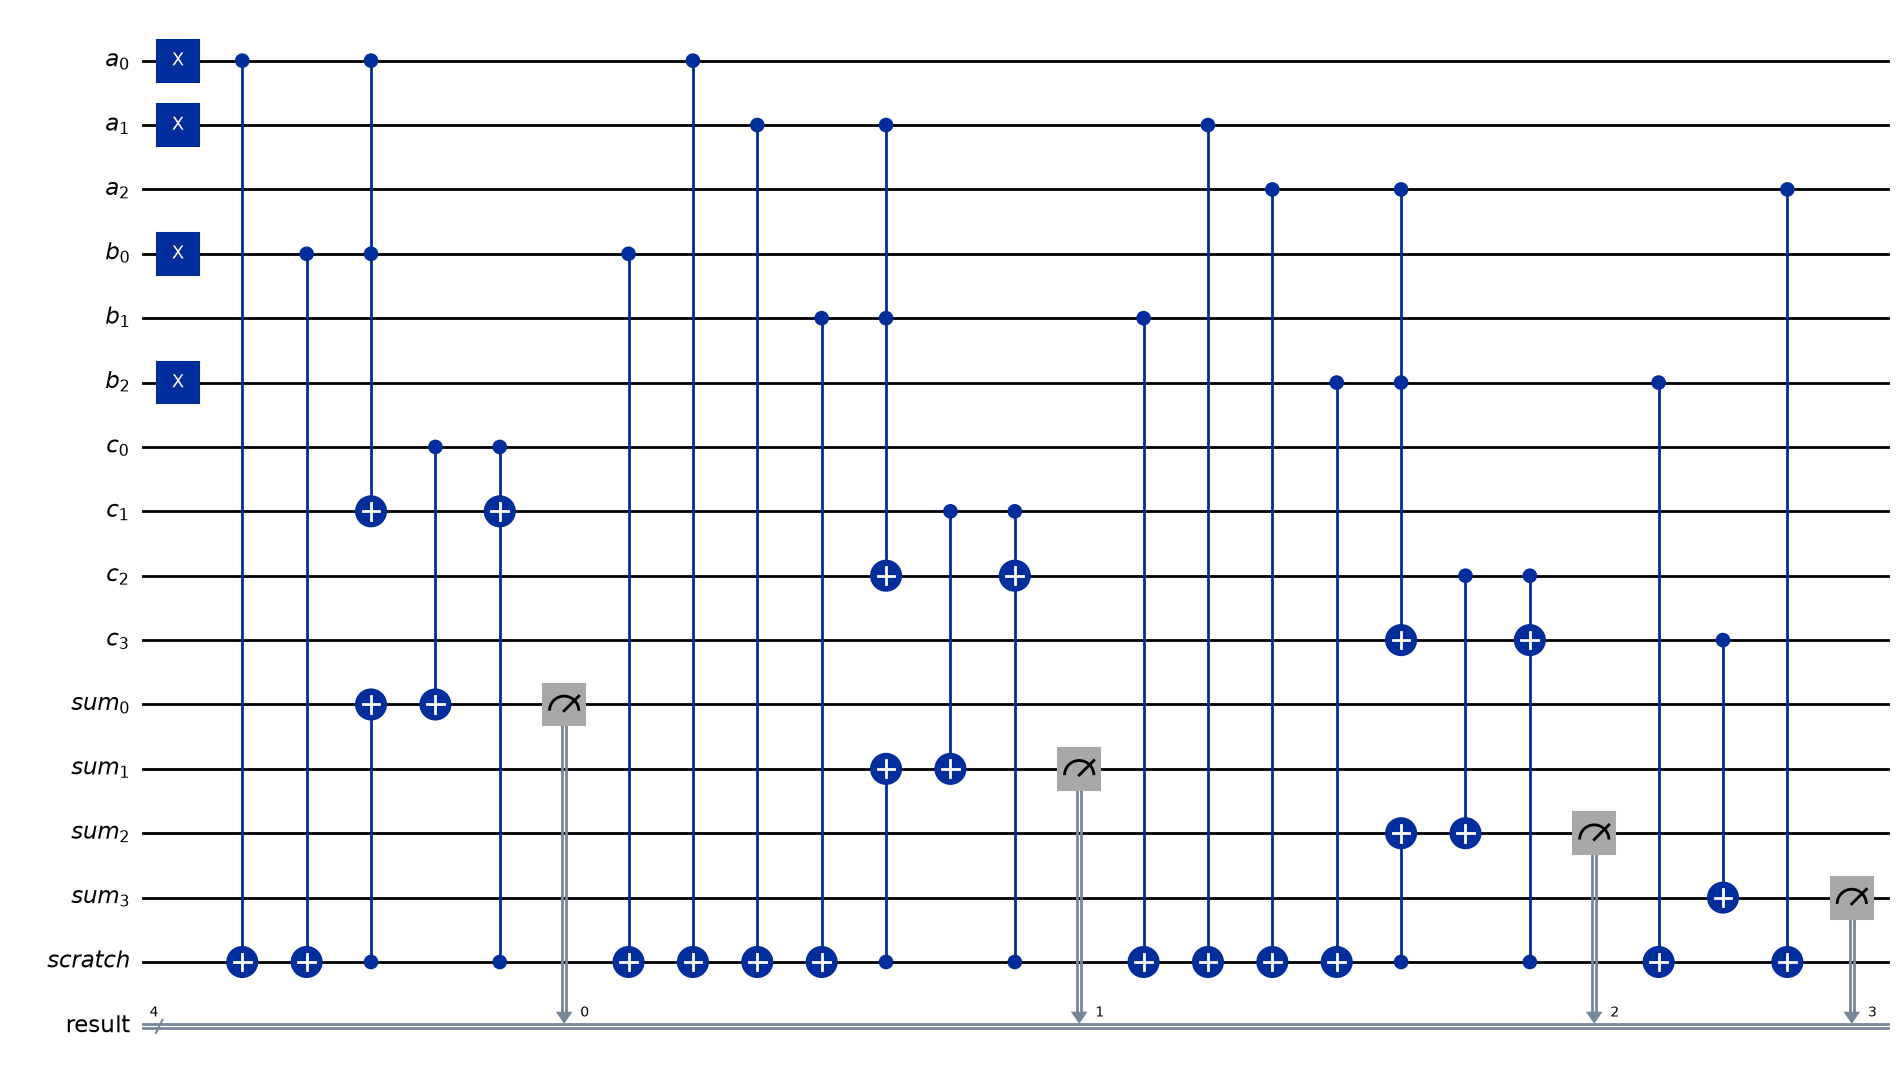

counts: {'1000': 1024}


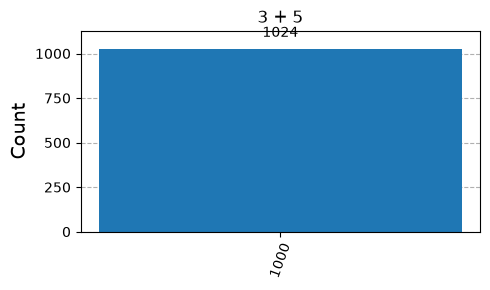

In [2]:
qc_add = build_adder(3, 5)
display(qc_add.draw("mpl", fold=90))
counts = backend.run(transpile(qc_add, backend), shots=1024).result().get_counts()
print("counts:", counts)
display(plot_histogram(counts, title="3 + 5", figsize=(5, 3)))

## 3. Addition: $6 + 2 = 8$

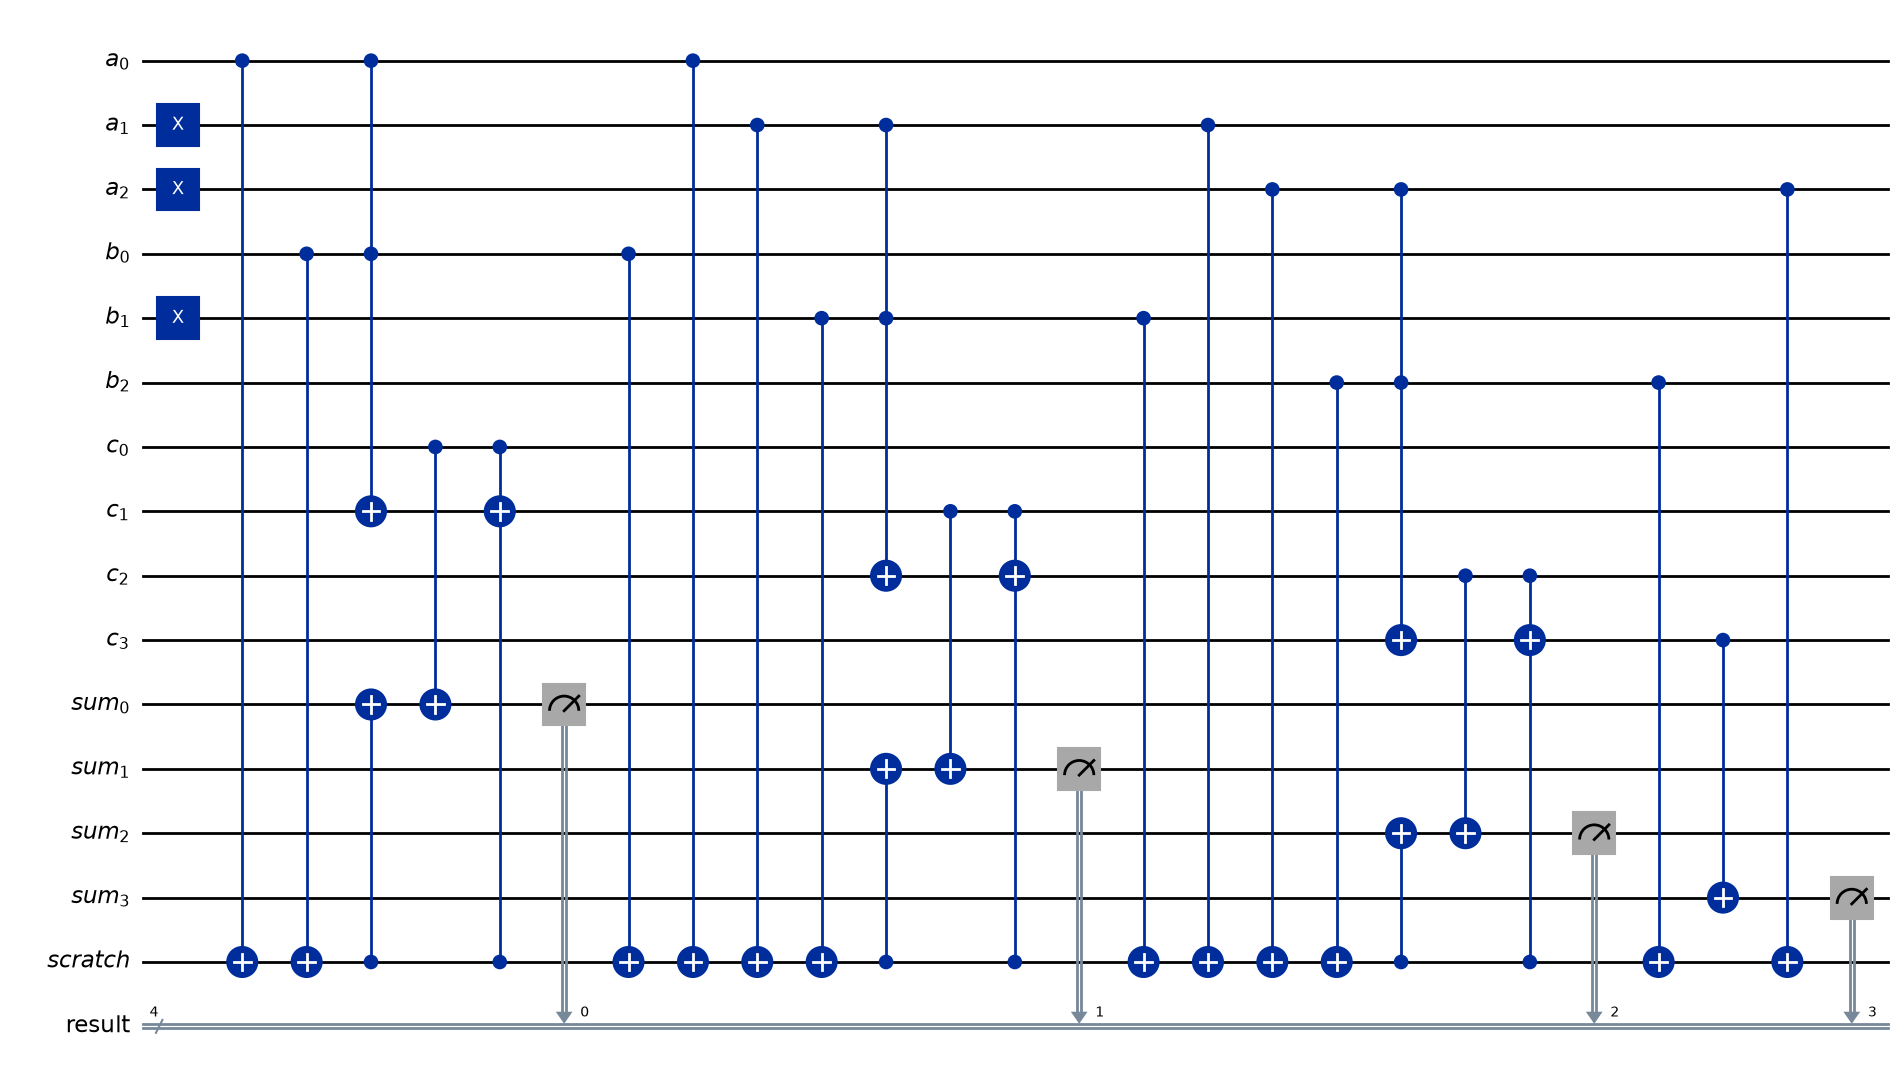

counts: {'1000': 1024}


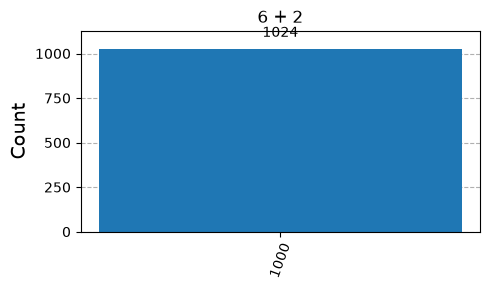

In [3]:
qc_add2 = build_adder(6, 2)
display(qc_add2.draw("mpl", fold=90))
counts = backend.run(transpile(qc_add2, backend), shots=1024).result().get_counts()
print("counts:", counts)
display(plot_histogram(counts, title="6 + 2", figsize=(5, 3)))

## 4. Subtraction: $7 - 3 = 4$

Two's complement: $a - b = a + (\sim b) + 1$. The extra $+1$ is an X gate on the initial carry.

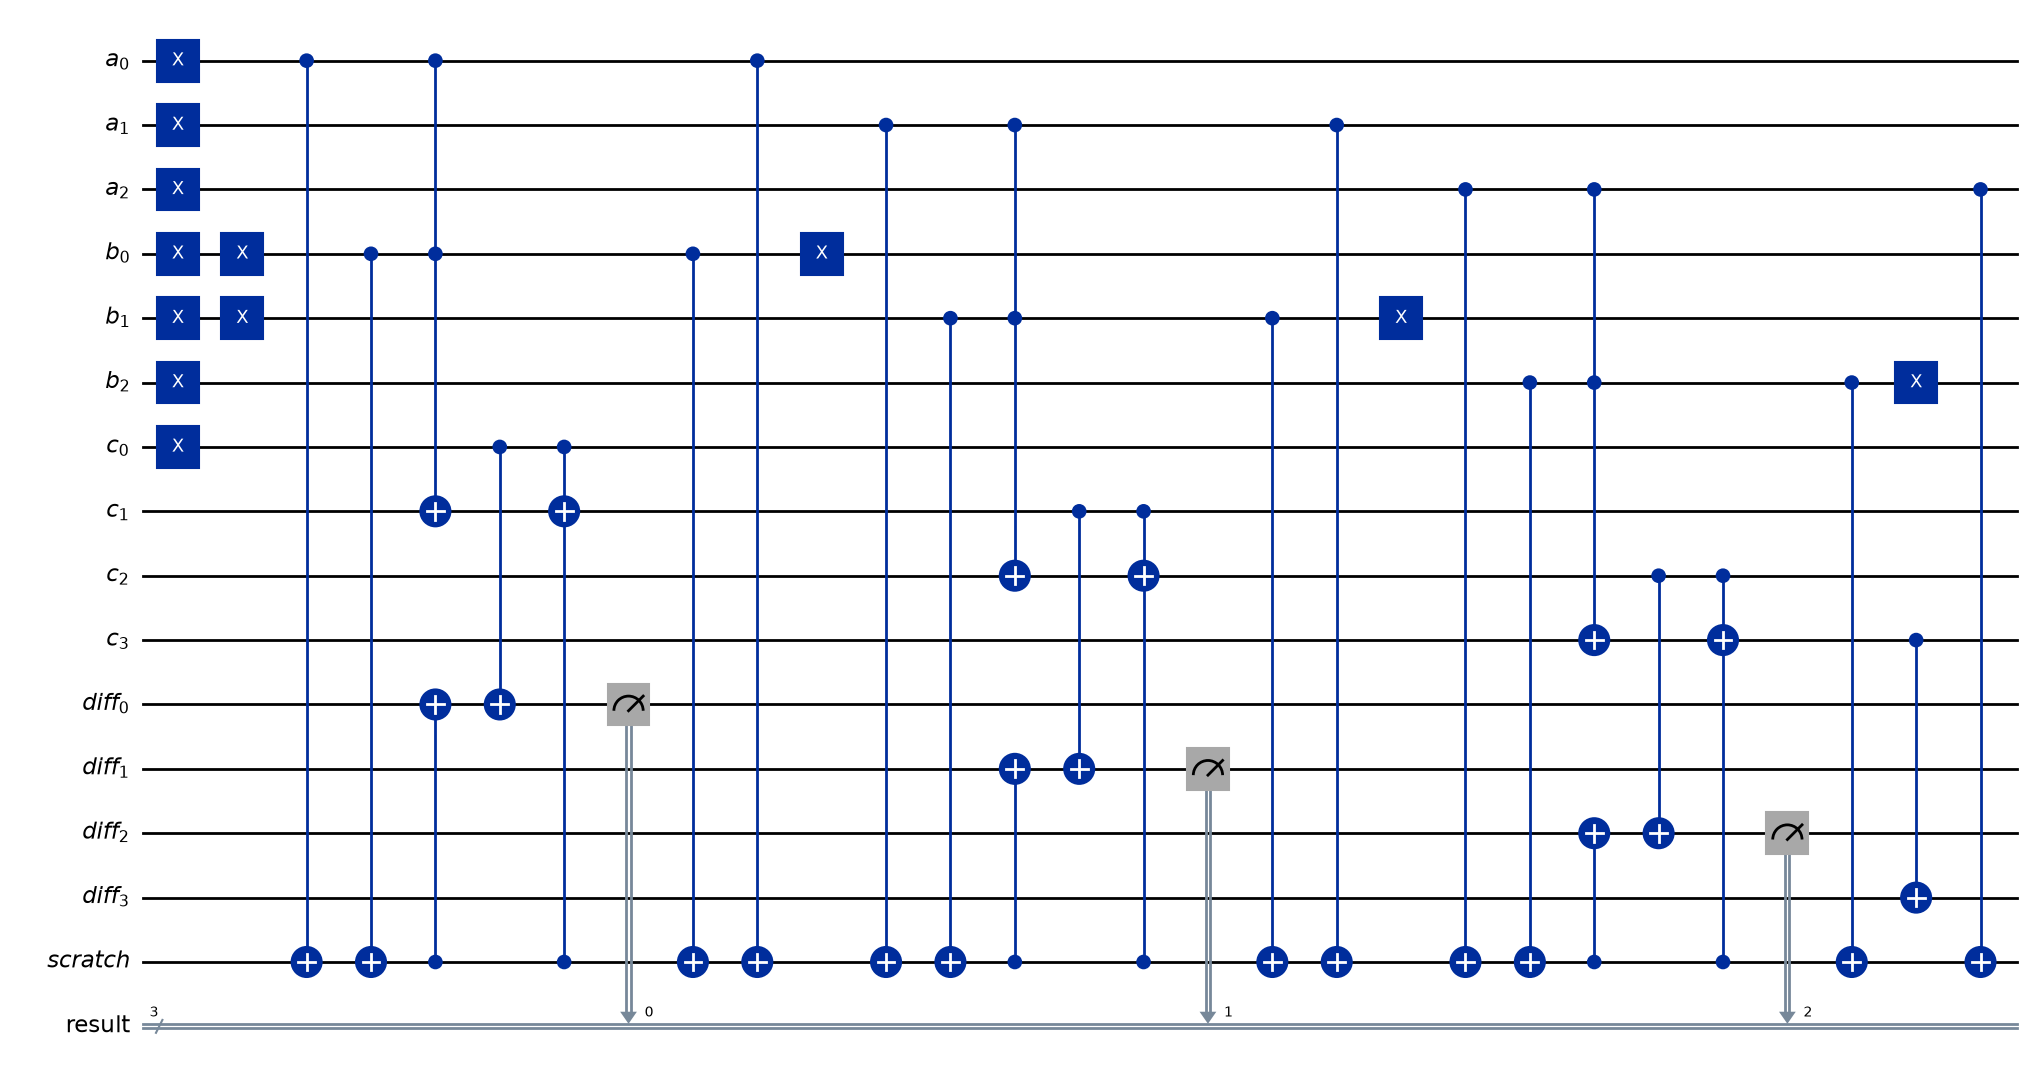

counts: {'100': 1024}


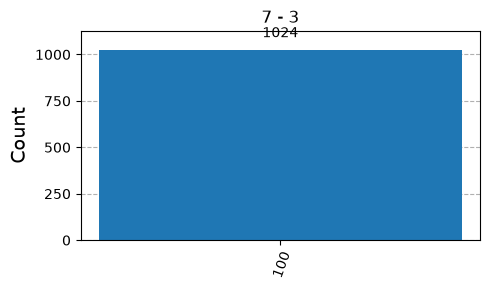

In [4]:
qc_sub = build_subtractor(7, 3)
display(qc_sub.draw("mpl", fold=90))
counts = backend.run(transpile(qc_sub, backend), shots=1024).result().get_counts()
print("counts:", counts)
display(plot_histogram(counts, title="7 - 3", figsize=(5, 3)))

## 5. Subtraction: $5 - 1 = 4$

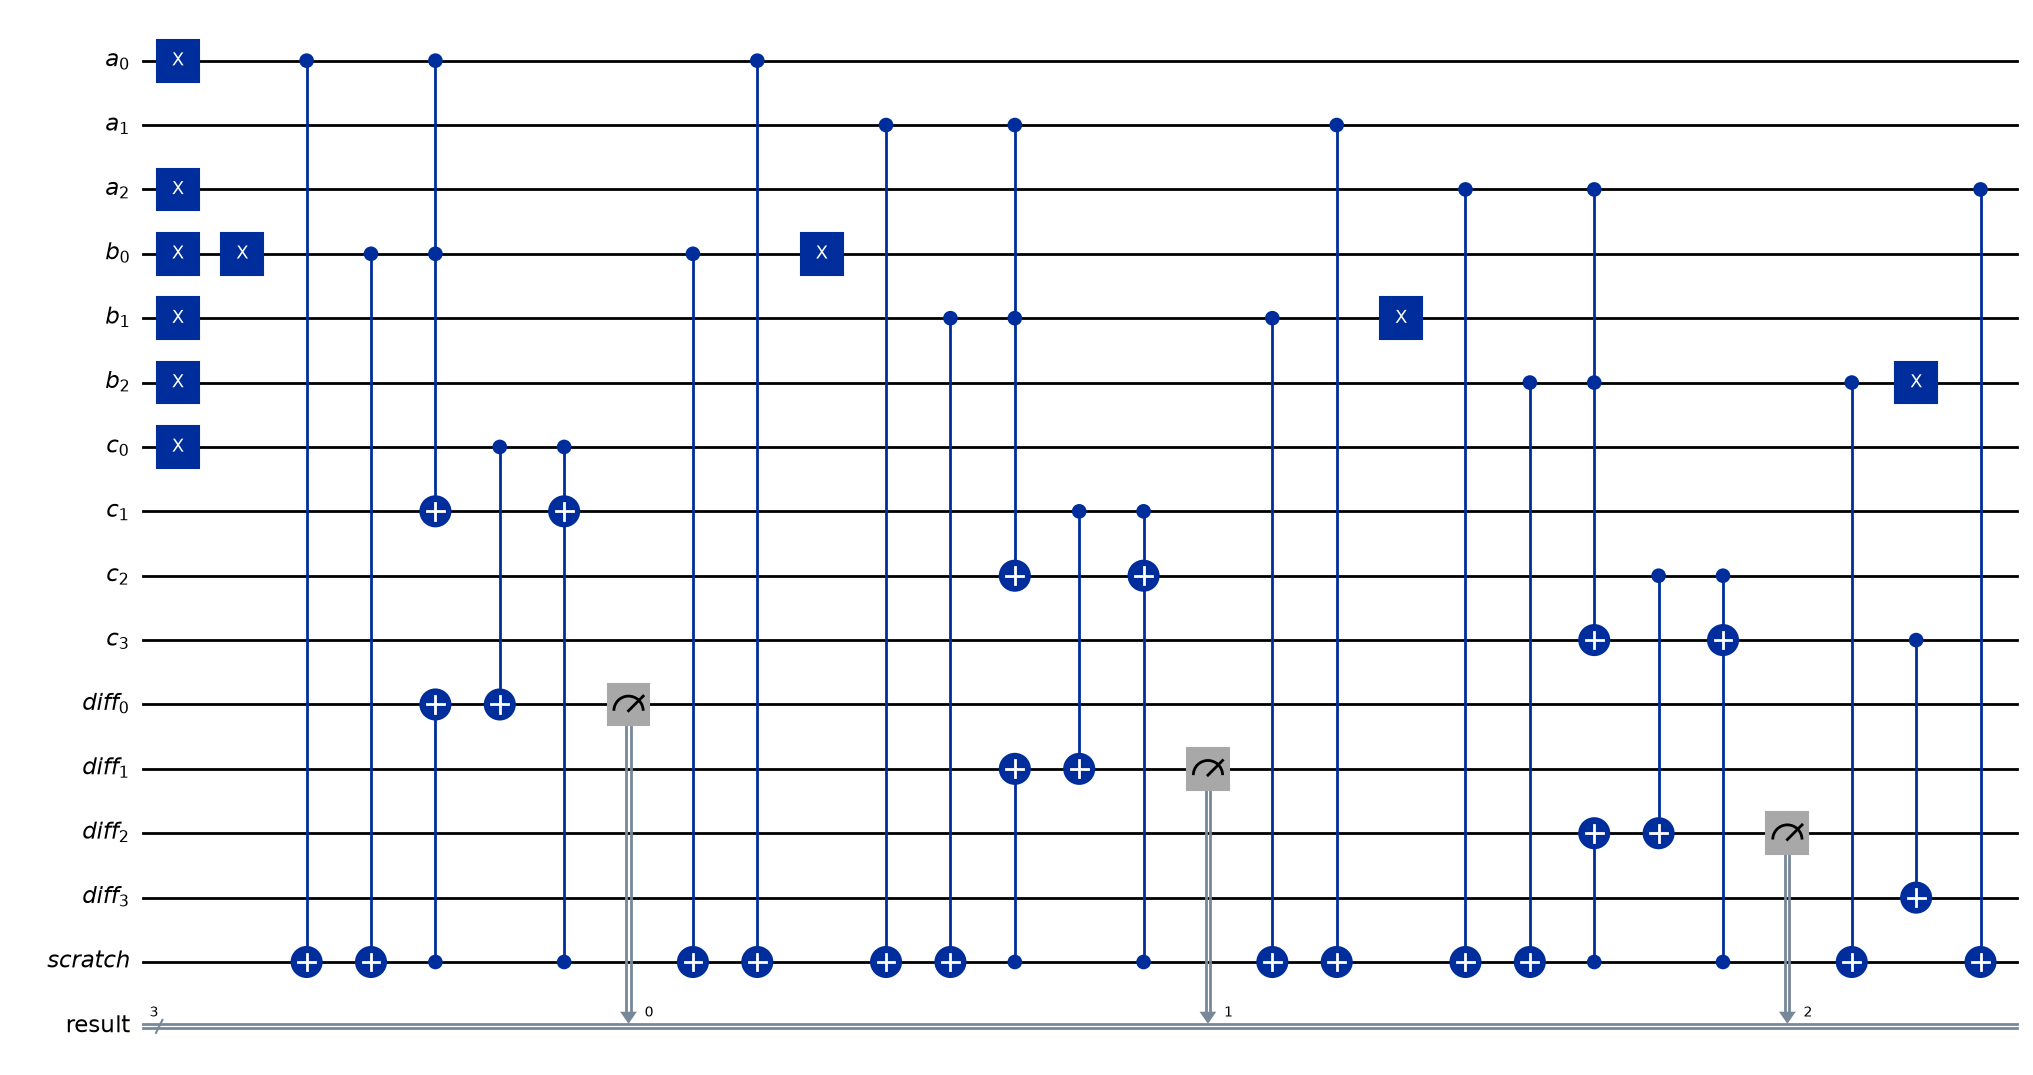

counts: {'100': 1024}


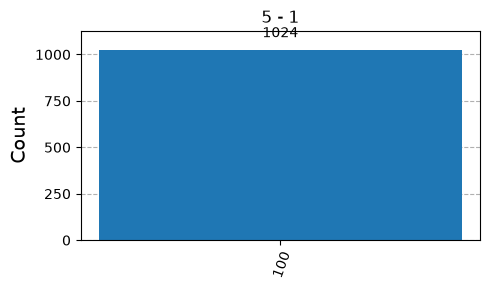

In [5]:
qc_sub2 = build_subtractor(5, 1)
display(qc_sub2.draw("mpl", fold=90))
counts = backend.run(transpile(qc_sub2, backend), shots=1024).result().get_counts()
print("counts:", counts)
display(plot_histogram(counts, title="5 - 1", figsize=(5, 3)))

## 6. Summary

| Operation | Instance | Expected | Result |
|---|---|---|---|
| addition | $3+5$ | 8 | 8 on every shot |
| addition | $6+2$ | 8 | 8 on every shot |
| subtraction | $7-3$ | 4 | 4 on every shot |
| subtraction | $5-1$ | 4 | 4 on every shot |

The same functions live in `calculator.py` (`python calculator.py`).